# Modelo de regresion Logistica final

In [1]:
# Incluir librerias a utilizar
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Carga y limpieza inicial
Estas son transformaciones que dependen de la lógica del negocio y se hacen antes del pipeline.

In [2]:
df = pd.read_csv('archive/base.csv') # Asegúrate que el nombre del archivo sea correcto

In [3]:
# Manejo de valores centinela (-1)
df['prev_address_unknown'] = df['prev_address_months_count'].apply(lambda x: 1 if x == -1 else 0)
df['prev_address_months_count'] = df['prev_address_months_count'].replace(-1, 0)
df['bank_months_unknown'] = df['bank_months_count'].apply(lambda x: 1 if x == -1 else 0)
df['bank_months_count'] = df['bank_months_count'].replace(-1, 0)
median_session = df[df['session_length_in_minutes'] != -1]['session_length_in_minutes'].median()
df['session_length_in_minutes'] = df['session_length_in_minutes'].replace(-1, median_session)

# Eliminación de columnas correlacionadas
df = df.drop(columns=['velocity_6h', 'velocity_24h'])

## PREPARACIÓN PARA EL PIPELINE

In [4]:
# 1. Separar características (X) y variable objetivo (y)
X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

# 2. Identificar columnas numéricas y categóricas que irán al pipeline
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. Dividir los datos ANTES de aplicar el pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## Construccion del pipeline

In [5]:
# Función personalizada para el recorte de outliers con IQR
def clip_outliers_iqr(df):
    df_copy = df.copy()
    for col in df_copy.columns:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        df_copy[col] = df_copy[col].clip(lower=limite_inferior, upper=limite_superior)
    return df_copy

# 4. Crear el pipeline para transformaciones numéricas
#    Paso 1: Recortar outliers.
#    Paso 2: Escalar los datos.
numeric_transformer = Pipeline(steps=[
    ('outlier_clipper', FunctionTransformer(clip_outliers_iqr)),
    ('scaler', StandardScaler())
])

# 5. Crear el pipeline para transformaciones categóricas
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 6. Combinar los pipelines con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Mantiene columnas que no se especificaron (si las hubiera)
)

# 7. Crear el pipeline final que une el preprocesador y el clasificador
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

## Entrenamiento y evalucion

Entrenando el pipeline...
Entrenamiento completado.

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    296691
           1       0.04      0.80      0.08      3309

    accuracy                           0.79    300000
   macro avg       0.52      0.80      0.48    300000
weighted avg       0.99      0.79      0.88    300000


--- Matriz de Confusión ---


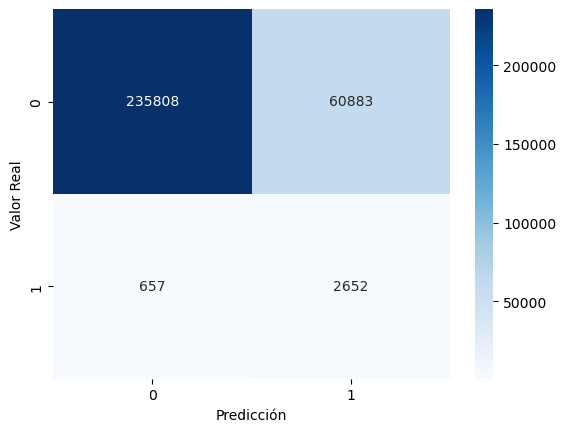

In [6]:
# 8. Entrenar todo el pipeline con una sola llamada
print("Entrenando el pipeline...")
model_pipeline.fit(X_train, y_train)
print("Entrenamiento completado.")

# 9. Hacer predicciones
y_pred = model_pipeline.predict(X_test)

# 10. Evaluar el rendimiento
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

In [2]:
from imblearn.over_sampling import SMOTE

# OJO: SMOTE se aplica SOLAMENTE al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Ahora, entrenarías tu modelo usando X_train_resampled y y_train_resampled
# Entrena el modelo con los datos balanceados
model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', class_weight='balanced', random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Escala X_test igual que X_train (ya lo hiciste antes)
X_test_scaled = scaler.transform(X_test)

c:\Users\edosa\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\edosa\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\edosa\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\edosa\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\edosa\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

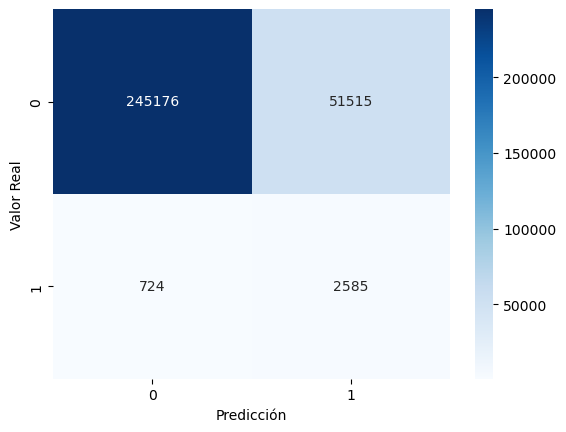

In [3]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Asumiendo que 'model' es tu regresión logística ya entrenada
# y 'X_test_scaled' y 'y_test' son tus datos de prueba
y_pred = model.predict(X_test_scaled)

# Genera la matriz
cm = confusion_matrix(y_test, y_pred)

# Visualízala
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

In [4]:
# Imprime un reporte completo
print(classification_report(y_test, y_pred, target_names=['No Fraude (0)', 'Fraude (1)']))

               precision    recall  f1-score   support

No Fraude (0)       1.00      0.83      0.90    296691
   Fraude (1)       0.05      0.78      0.09      3309

     accuracy                           0.83    300000
    macro avg       0.52      0.80      0.50    300000
 weighted avg       0.99      0.83      0.89    300000

